In [ ]:
from huggingface_hub import notebook_login

notebook_login()

### 配置 llama factory 环境

In [ ]:
git clone https://github.com/hiyouga/LLaMA-Factory.git
cd LLaMA-Factory
pip install -e .

In [ ]:
### llama factory 启动命令
llamafactory-cli webui

In [3]:
%pip install accelerate qwen-vl-utils[decord]==0.0.8
%pip install transformers==4.50.0
%pip install modelscope==1.24.0
%pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121
%pip install pillow requests python-dotenv
%pip install vllm==0.7.3
%pip install deepspeed
%pip install swanlab


Looking in indexes: http://mirrors.aliyun.com/pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: http://mirrors.aliyun.com/pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: http://mirrors.aliyun.com/pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu121
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: http://mirrors.aliyun.com/pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: http://mirrors.aliyun.com/pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: http://mirrors.aliyun.com/pypi/simple
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 67.2 MB/s eta 

### 数据集 下载

In [ ]:
huggingface-cli login --token hf_xxxxxx  # 登录账号并替换为真实Token
huggingface-cli download \
    --repo-type dataset \                # 指定下载类型为数据集
    --resume-download \                  # 启用断点续传
    --local-dir ./my_dataset \           # 自定义本地存储路径
    dataset_namespace/dataset_name       # 替换为实际数据集名称


In [ ]:
#真实下载命令
huggingface-cli login --token hf_xxx  
huggingface-cli download --repo-type dataset --local-dir /root/finetune_vl/LLaMA-Factory/llamafactory/RLHF-V  llamafactory/RLHF-V     

In [10]:
#数据集下载
from datasets import load_dataset

ds = load_dataset("llamafactory/RLHF-V", cache_dir = './dir')


ConnectionError: Couldn't reach 'llamafactory/RLHF-V' on the Hub (SSLError)

In [ ]:
#数据保存
ds.save_to_disk("/root/finetune_vl/LLaMA-Factory/llamafactory/RLHF-V2")


In [ ]:
#数据集从 本地 加载
from datasets import load_from_disk

dataset = load_from_disk("/root/finetune_vl/LLaMA-Factory/llamafactory/RLHF-V2")


### 模型下载

In [1]:
# model_download.py
#模型下载
from modelscope import snapshot_download
model_dir = snapshot_download('Qwen/Qwen2.5-VL-3B-Instruct', cache_dir='/root/autodl-tmp', revision='master')



2025-05-25 15:07:30,872 - modelscope - WARNING - Using branch: master as version is unstable, use with caution
2025-05-25 15:07:31,307 - modelscope - INFO - Got 14 files, start to download ...


Processing 14 items:   0%|          | 0.00/14.0 [00:00<?, ?it/s]

2025-05-25 15:14:16,289 - modelscope - INFO - Download model 'Qwen/Qwen2.5-VL-3B-Instruct' successfully.
2025-05-25 15:14:16,292 - modelscope - INFO - Creating symbolic link [/root/autodl-tmp/Qwen/Qwen2.5-VL-3B-Instruct].


### 使用webui 页面配置微调参数

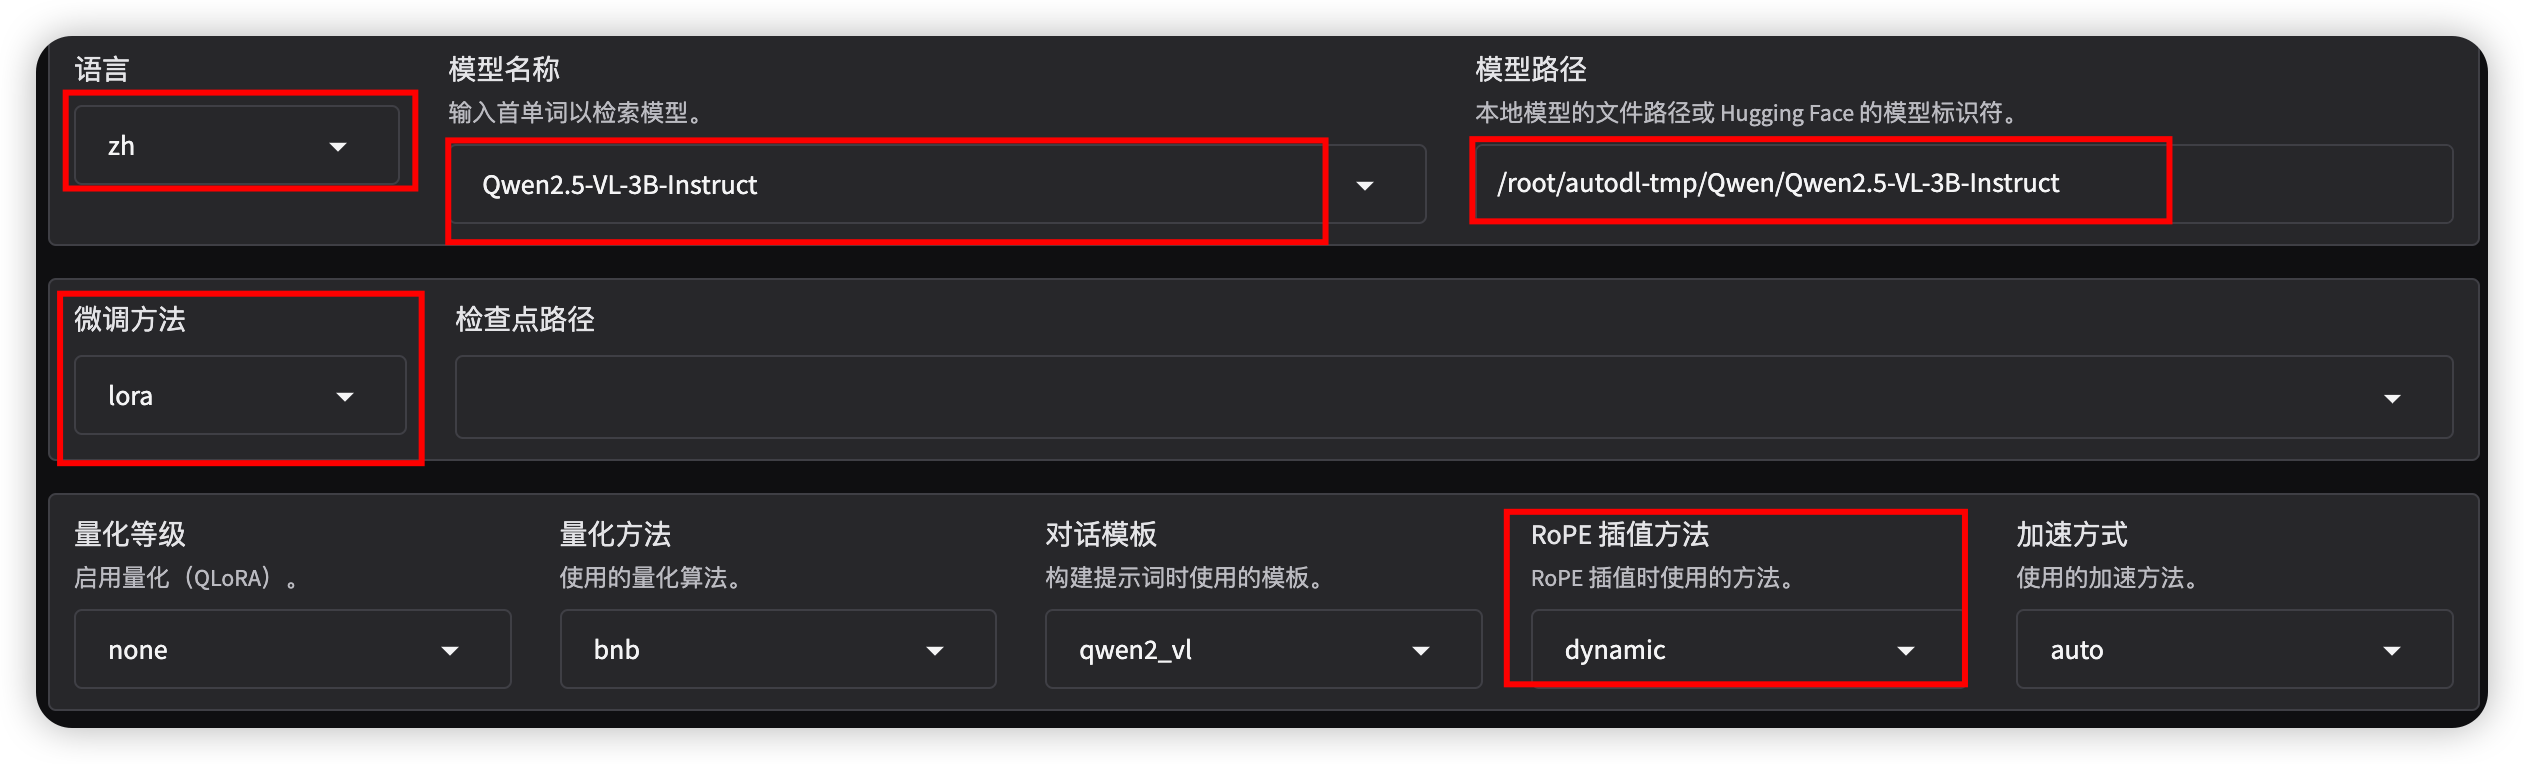

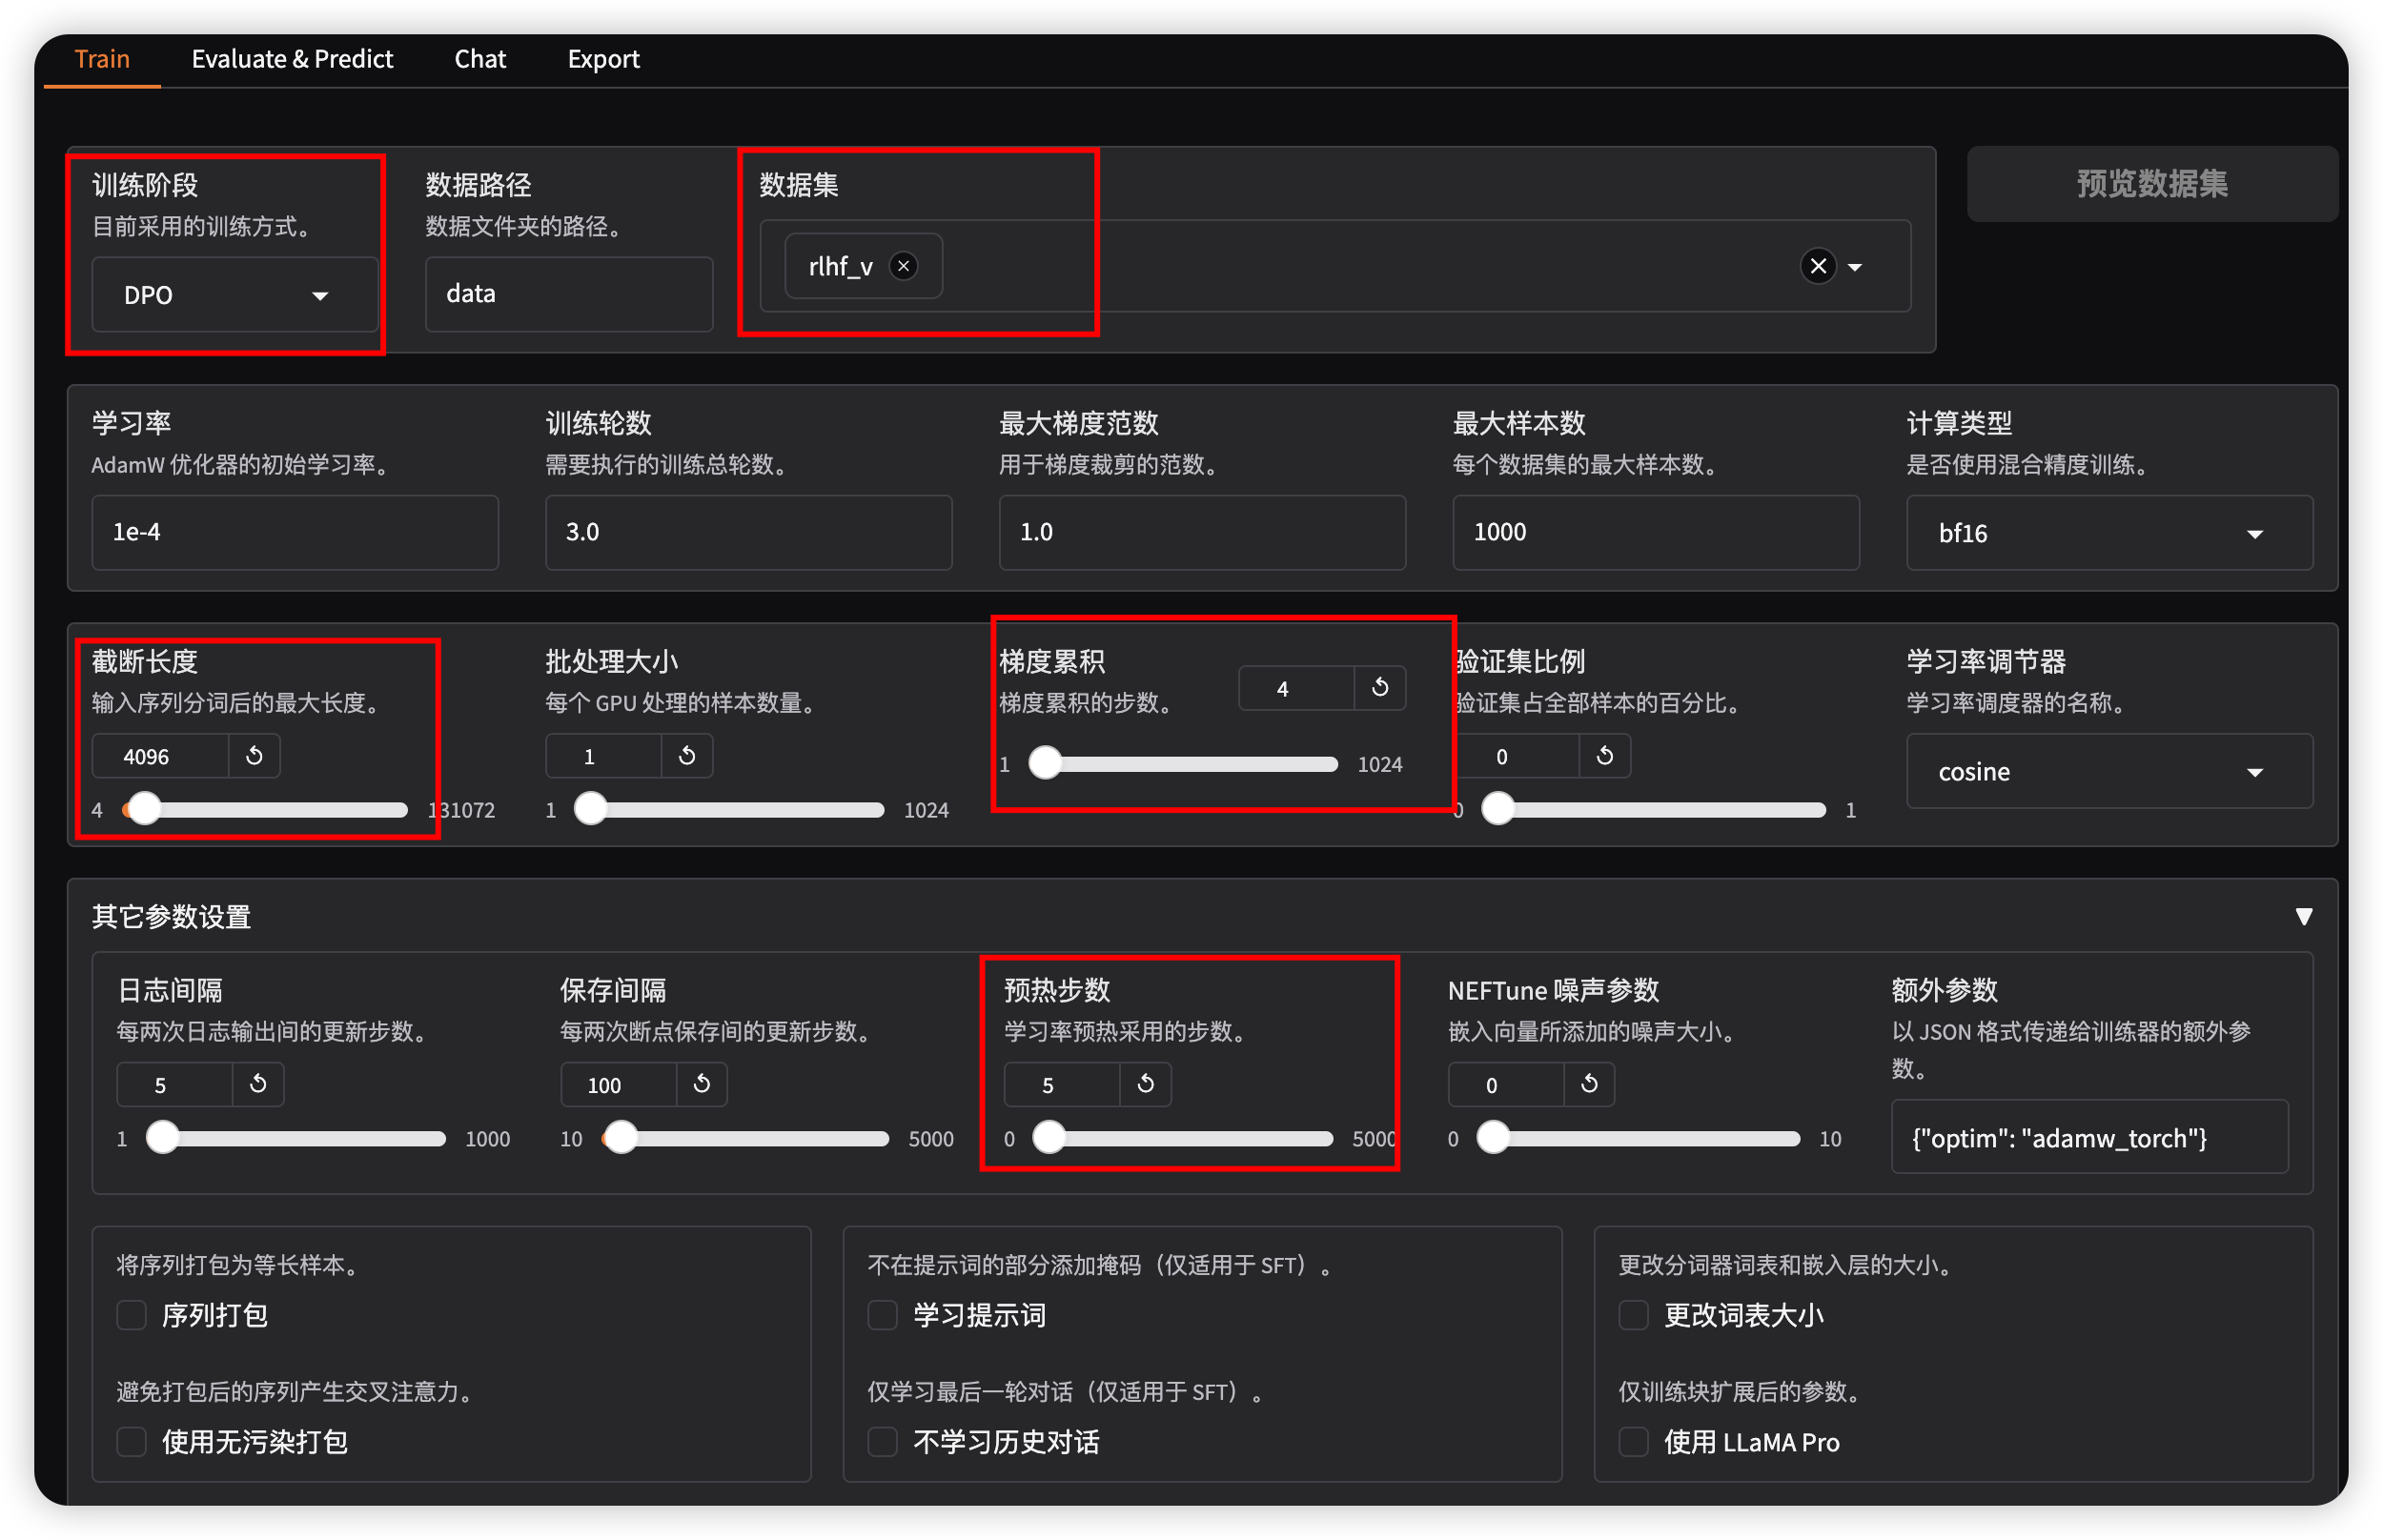

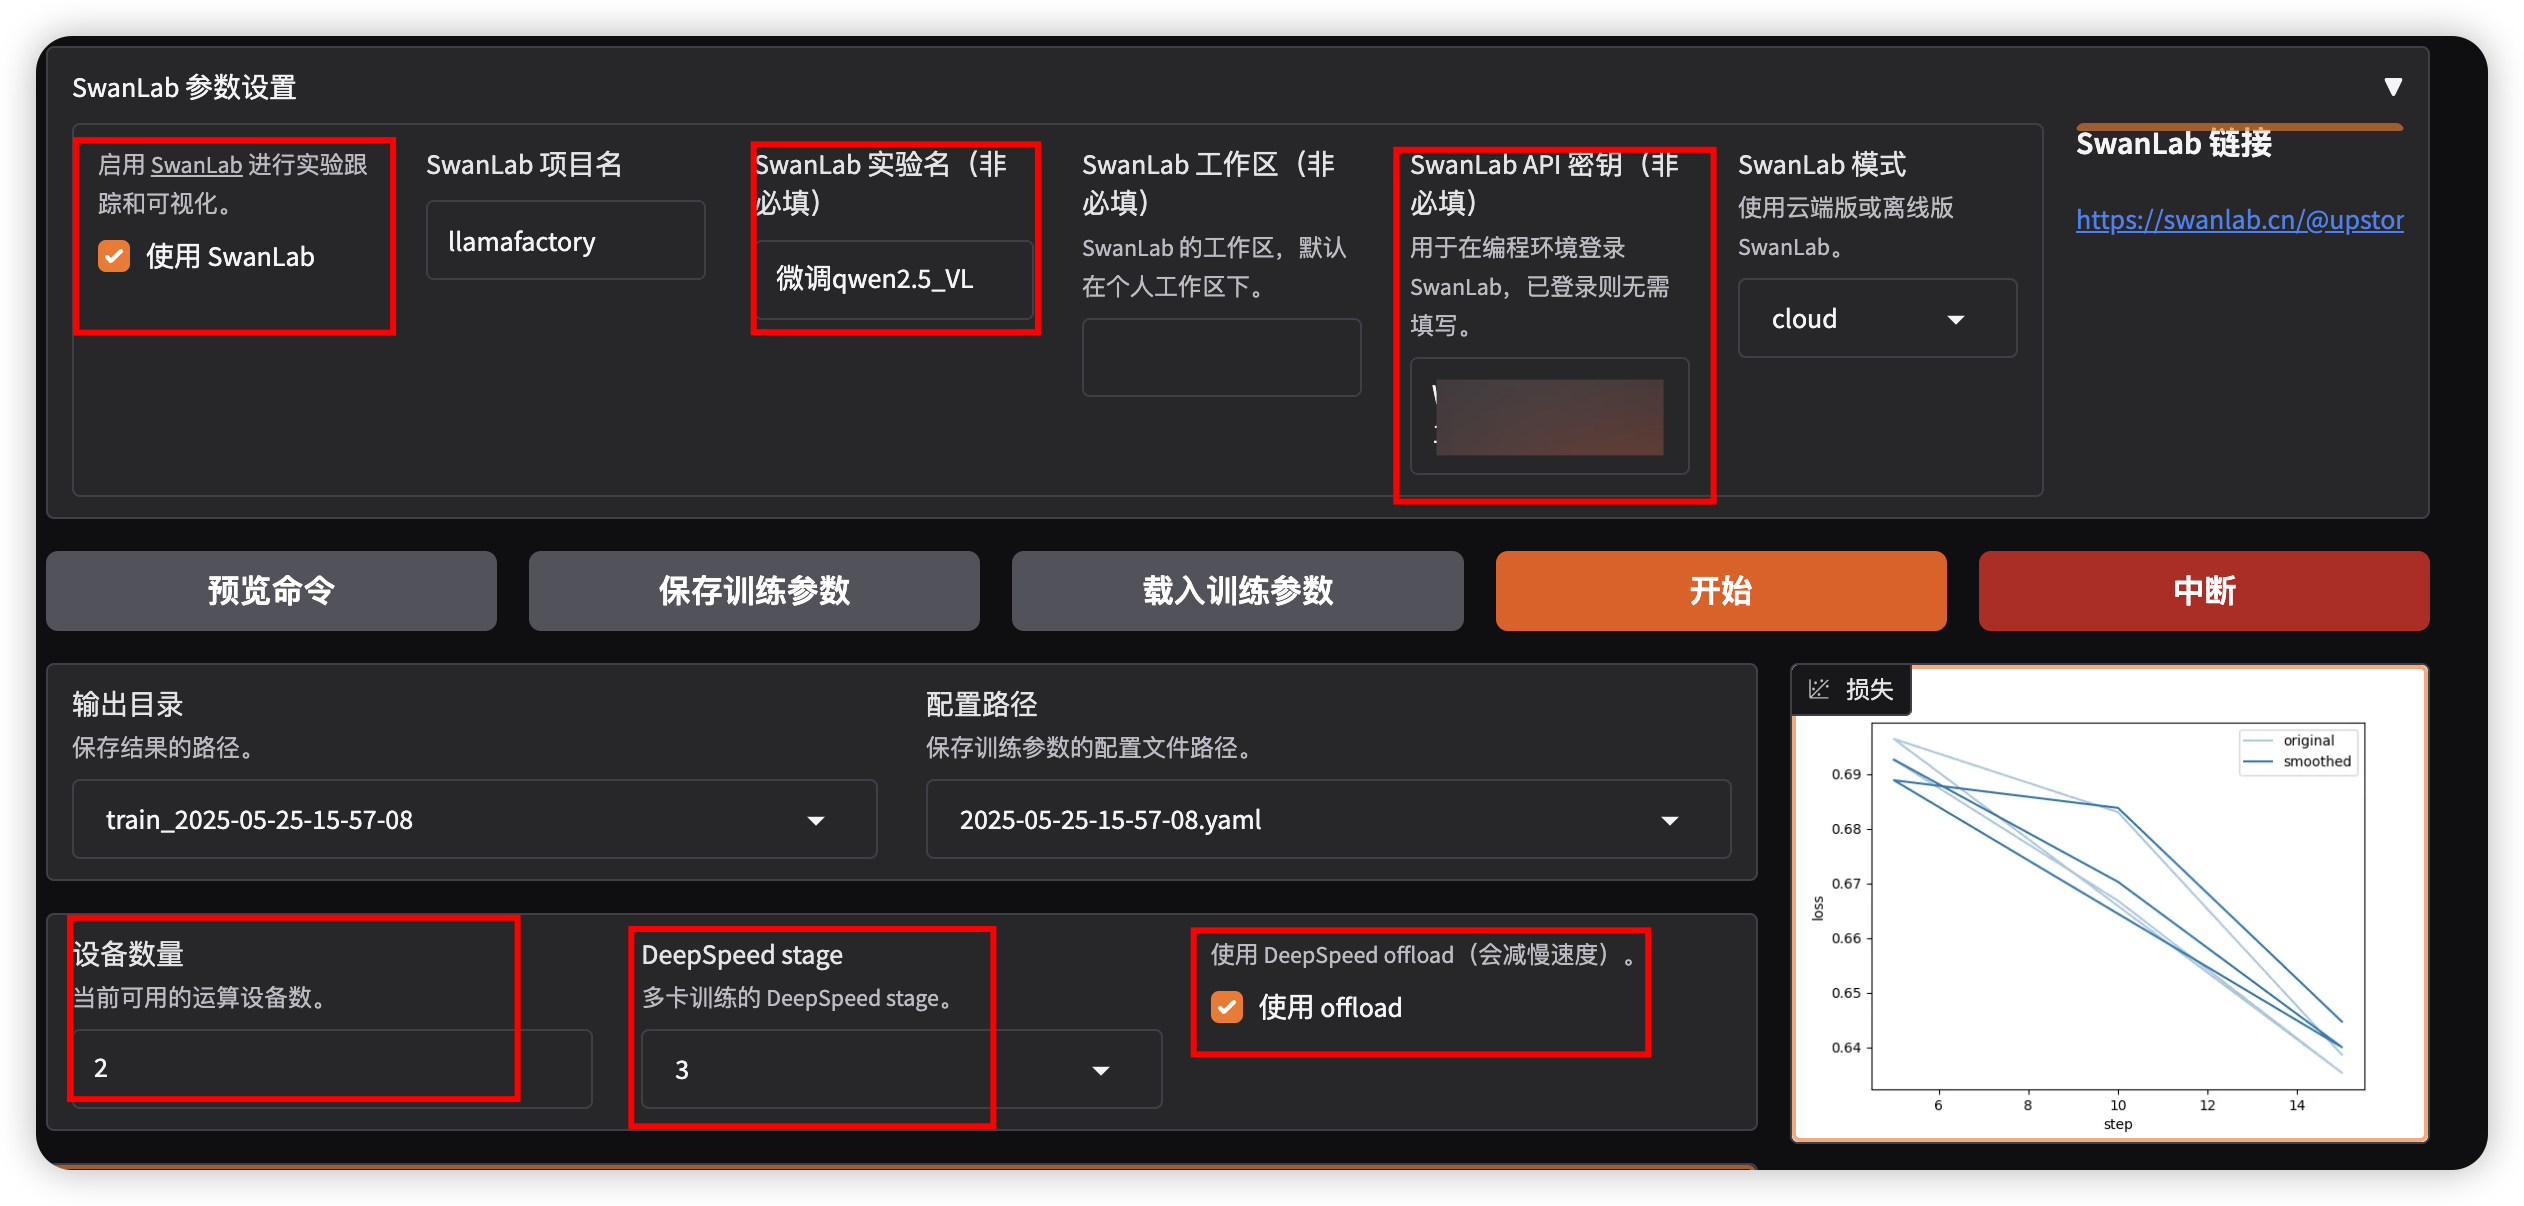

### 配置完成后参数如下

In [ ]:
llamafactory-cli train \
    --stage dpo \
    --do_train True \
    --model_name_or_path /root/autodl-tmp/Qwen/Qwen2.5-VL-3B-Instruct \
    --preprocessing_num_workers 16 \
    --finetuning_type lora \
    --template qwen2_vl \
    --rope_scaling dynamic \
    --flash_attn auto \
    --dataset_dir data \
    --dataset rlhf_v \
    --cutoff_len 4096 \
    --learning_rate 0.0001 \
    --num_train_epochs 3.0 \
    --max_samples 100 \
    --per_device_train_batch_size 2 \
    --gradient_accumulation_steps 4 \
    --lr_scheduler_type cosine \
    --max_grad_norm 1.0 \
    --logging_steps 5 \
    --save_steps 100 \
    --warmup_steps 0 \
    --packing False \
    --enable_thinking True \
    --report_to none \
    --freeze_vision_tower True \
    --freeze_multi_modal_projector True \
    --image_max_pixels 589824 \
    --image_min_pixels 1024 \
    --video_max_pixels 65536 \
    --video_min_pixels 256 \
    --use_swanlab True \
    --output_dir saves/Qwen2.5-VL-3B-Instruct/lora/train_2025-05-25-15-30-16 \
    --bf16 True \
    --plot_loss True \
    --trust_remote_code True \
    --ddp_timeout 180000000 \
    --include_num_input_tokens_seen True \
    --optim adamw_torch \
    --lora_rank 8 \
    --lora_alpha 16 \
    --lora_dropout 0 \
    --lora_target all \
    --pref_beta 0.1 \
    --pref_ftx 0 \
    --pref_loss sigmoid \
    --swanlab_project llamafactory \
    --swanlab_run_name 微调qwen2.5_VL \
    --swanlab_api_key WR3sOT2SwuKxwP1vEo8pa \
    --swanlab_mode cloud \
    --deepspeed cache/ds_z3_offload_config.json